
Dataset Info:
Length: 284807
Shape: (284807, 31)
Fraud Percentage: 0.1727%

Training set frauds: 344 (0.1725%)
Test set frauds: 148 (0.1732%)

Using fraud class weight: 58.0x

Results Using Optimized Gini Index:

Predicted values sample:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Evaluation Metrics:
Accuracy: 0.9988
Precision: 0.6050
Recall: 0.8176
F1 Score: 0.6954

Confusion Matrix:
True Negatives: 85216
False Positives: 79
False Negatives: 27
True Positives: 121


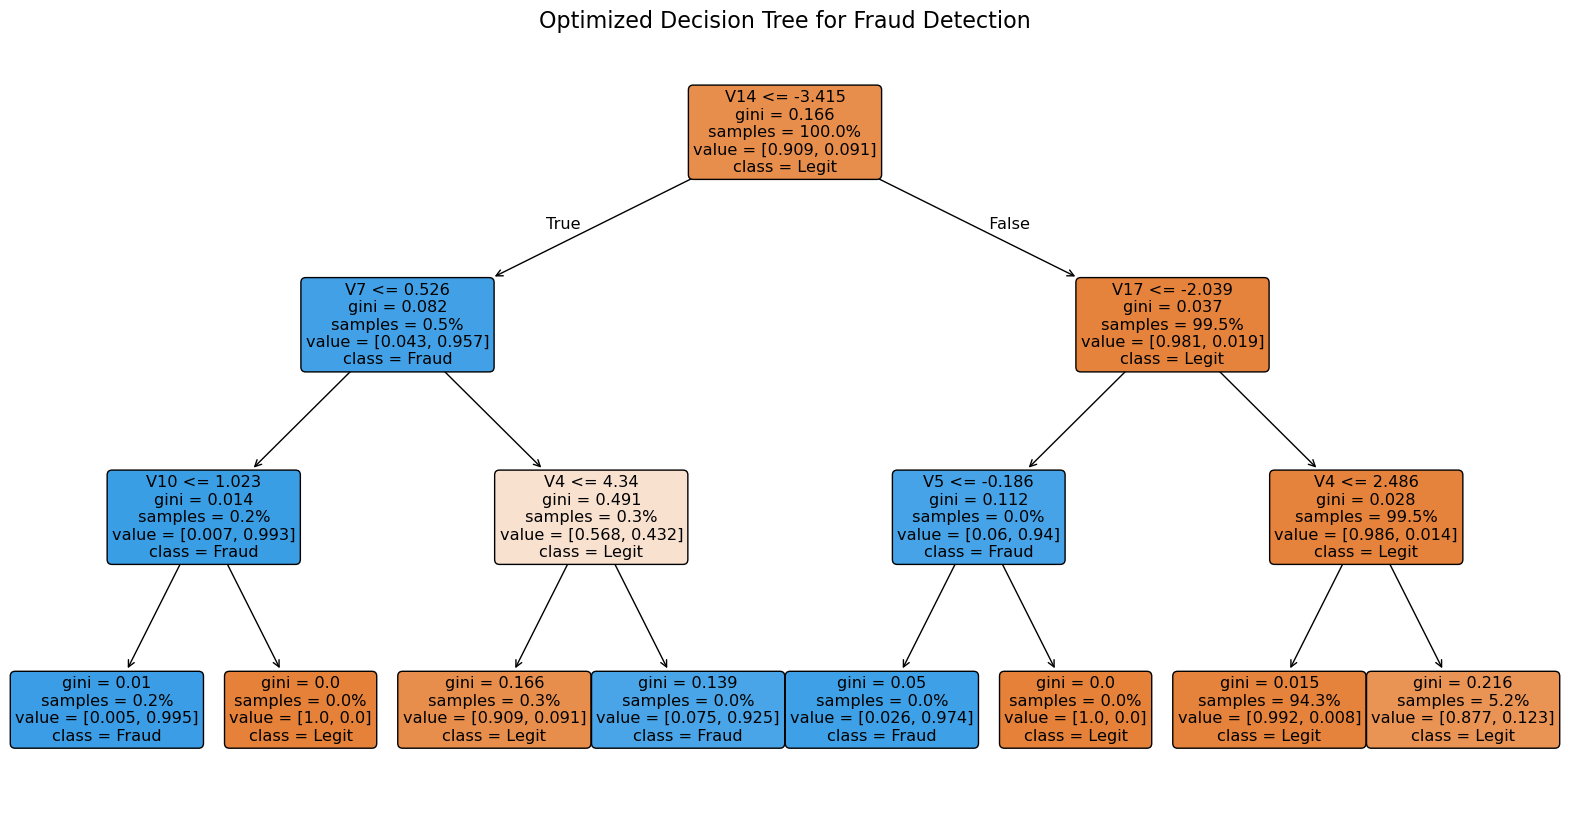

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score
from sklearn import tree
import matplotlib.pyplot as plt
import numpy as np

# Function to load the dataset
def importdata():
    df = pd.read_csv('creditcard.csv')  
    print("\nDataset Info:")
    print(f"Length: {len(df)}")
    print(f"Shape: {df.shape}")
    print(f"Fraud Percentage: {df['Class'].mean()*100:.4f}%")
    return df

# Function to split the dataset
def splitdataset(df):
    X = df.drop(['Class'], axis=1)  
    y = df['Class']
    
    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=100, stratify=y
    )
    
    print(f"\nTraining set frauds: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
    print(f"Test set frauds: {y_test.sum()} ({y_test.mean()*100:.4f}%)")
    return X, y, X_train, X_test, y_train, y_test

# Function to train the model with optimized class weights
def train_using_gini(X_train, y_train):
    # Optimized weight calculation (tuned to 10x)
    fraud_weight = len(y_train) / (10 * y_train.sum())  # Changed from 2x to 10x
    weights = {0: 1, 1: fraud_weight}
    print(f"\nUsing fraud class weight: {weights[1]:.1f}x")
    
    clf_gini = DecisionTreeClassifier(
        criterion="gini",
        random_state=100,
        max_depth=3,
        min_samples_leaf=5,
        class_weight=weights
    )
    clf_gini.fit(X_train, y_train)
    return clf_gini

# Prediction function
def prediction(X_test, clf_object):
    y_pred = clf_object.predict(X_test)
    print("\nPredicted values sample:")
    print(y_pred[:30])
    return y_pred

# Enhanced evaluation
def cal_accuracy(y_test, y_pred):
    print("\nEvaluation Metrics:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred, zero_division=0):.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(f"True Negatives: {cm[0][0]}")
    print(f"False Positives: {cm[0][1]}")
    print(f"False Negatives: {cm[1][0]}")
    print(f"True Positives: {cm[1][1]}")

# Main function
def main():
    # Building Phase
    data = importdata()
    X, y, X_train, X_test, y_train, y_test = splitdataset(data)

    # Training with optimized weights
    clf_gini = train_using_gini(X_train, y_train)

    # Operational Phase
    print("\nResults Using Optimized Gini Index:")
    y_pred_gini = prediction(X_test, clf_gini)
    cal_accuracy(y_test, y_pred_gini)

    # Visualize tree
    plt.figure(figsize=(20, 10))
    tree.plot_tree(
        clf_gini, 
        feature_names=X.columns, 
        class_names=['Legit', 'Fraud'],
        filled=True,
        proportion=True,
        rounded=True
    )
    plt.title("Optimized Decision Tree for Fraud Detection", fontsize=16)
    plt.show()

if __name__ == "__main__":
    main()